<a href="https://colab.research.google.com/github/Neethu-Sathyan/python_eda/blob/main/HelmNet_Full_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [ ]:
!pip install tensorflow[and-cuda] numpy==1.25.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 77.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.19.0


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import os
import random
# Importing numpy for Matrix Operations
import numpy as np
# Importing pandas to read CSV files
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg
# Importting matplotlib for Plotting and visualizing images
import matplotlib.pyplot as plt
# Importing math module to perform mathematical operations
import math
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
# Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Importing the sequential module to define a sequential model
from tensorflow.keras.models import Sequential
# Defining all the layers to build our CNN Model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization
# Importing the optimizers which can be used in our model
from tensorflow.keras.optimizers import Adam,SGD
# Importing the preprocessing module to preprocess the data
from sklearn import preprocessing
# Importing train_test_split function to split the data into train and test
from sklearn.model_selection import train_test_split
# Importing confusion_matrix to plot the confusion matrix
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report


from sklearn.metrics import mean_squared_error as mse
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# **Data Overview**


##Loading the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the image file of the dataset
safety_helmet_images = np.load('/content/drive/MyDrive/GreatLearning/Introduction_to_CV/Assessment/images_proj.npy')

# Load the labels file of the dataset
safety_helmet_labels = pd.read_csv('/content/drive/MyDrive/GreatLearning/Introduction_to_CV/Assessment/Labels_proj.csv')

###

### Shapes of the images and lablels

In [ ]:
print(safety_helmet_images.shape)
print(safety_helmet_labels.shape)

(631, 200, 200, 3)
(631, 1)


* There are 631 RGB  images of shape 200 x 200 X 3, each image having 3 channels.
* There are 631 corresponding labels of the images

1


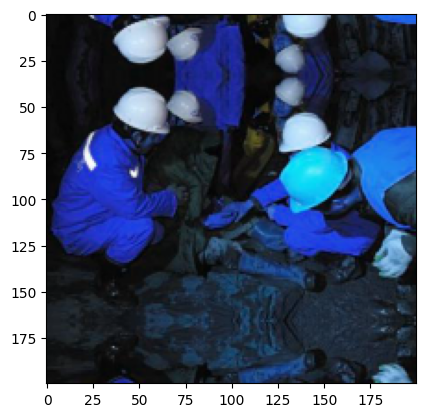

In [ ]:
plt.imshow(safety_helmet_images[4])
print(safety_helmet_labels['Label'][4])

# **Exploratory Data Analysis**

In [ ]:
# Converting the images from BGR to RGB using cvtColor function of OpenCV
for i in range(len(safety_helmet_images)):
  safety_helmet_images[i] = cv2.cvtColor(safety_helmet_images[i], cv2.COLOR_BGR2RGB)

###Plot random images from each of the classes and print their corresponding labels.

In [ ]:
def plot_images(images,labels):
  # Number of Classes
  num_classes=2
  categories=np.unique(labels)
  keys=dict(labels['Label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index])                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

In [ ]:
def plot_gray_images(images,labels):
  num_classes=10                                                                  # Number of Classes
  categories=np.unique(labels)
  keys=dict(labels['Label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index],cmap='gray')                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

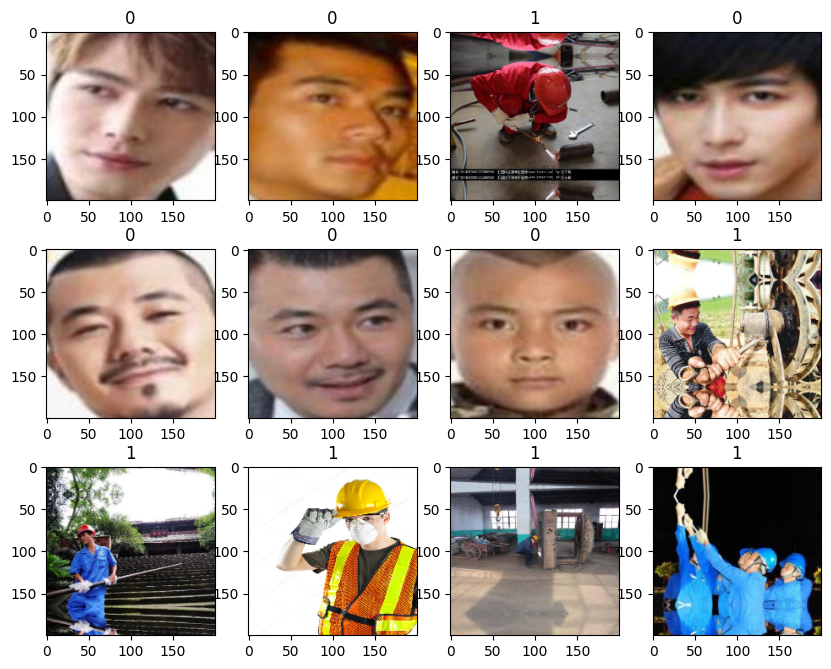

In [ ]:
plot_images(safety_helmet_images,safety_helmet_labels)

###Check the missing value in label


In [ ]:
safety_helmet_labels.isnull().sum()

,0
Label,0


* There is no null values of labels

## Checking for class imbalance


Label
0    320
1    311
Name: count, dtype: int64


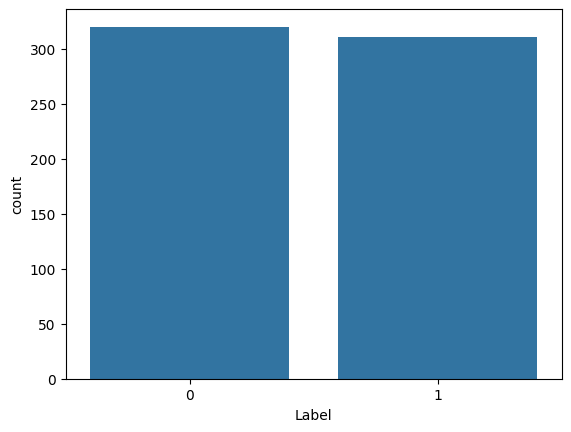

In [ ]:
# This shows how many of each label exists directly
sns.countplot(data=safety_helmet_labels, x='Label')
print(safety_helmet_labels['Label'].value_counts())

* There are two labels 0 and 1.
   - 0 : without helmet
   - 1 : with helmet
*  There is no significant difference between count of labels. So there is no class imbalance   

# **Data Preprocessing**

* To optimize computational efficiency for the 631-image dataset, the original $200 \times 200$ RGB images were downsampled to $64 \times 64$ pixels and converted to grayscale. To maintain compatibility with the CNN and VGG 16 architecture, these processed images were subsequently expanded back to a three-channel format.

## Converting images to grayscale

In [ ]:
gray_images = [cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), (64, 64)) for img in safety_helmet_images]

In [ ]:
reshaped_list = [img.reshape(64, 64, 1) for img in gray_images]

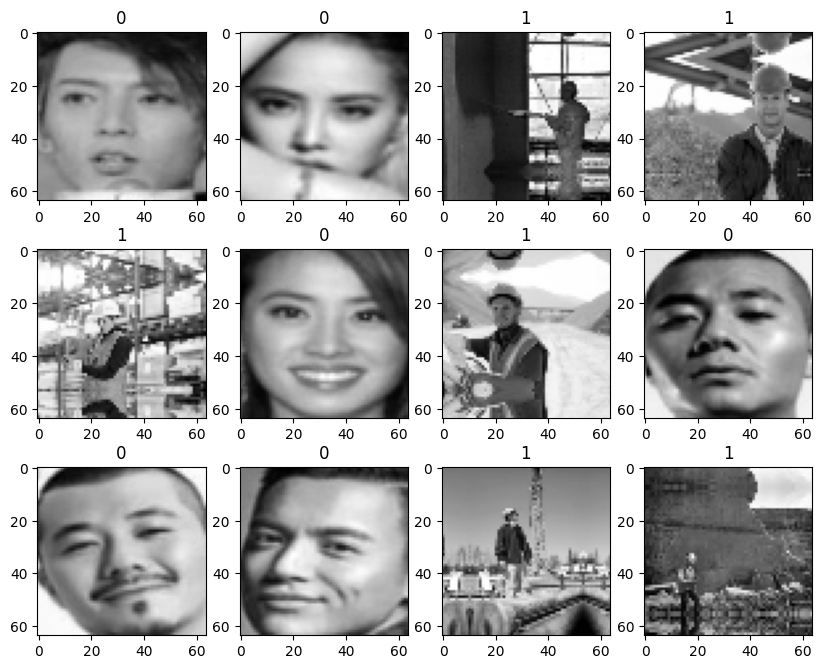

In [ ]:
plot_gray_images(reshaped_list,safety_helmet_labels)

In [ ]:
# Convert the existing reshaped_list (which is 64x64x1) to 3 channels
three_channel_safety_helmet_list = [np.repeat(img, 3, axis=-1) for img in reshaped_list]

# Check the new shape
print(three_channel_safety_helmet_list[0].shape)  # Output: (64, 64, 3)

(64, 64, 3)


### Splitting the dataset



In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(three_channel_safety_helmet_list),safety_helmet_labels , test_size=0.2, random_state=42,stratify=safety_helmet_labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [ ]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)


(504, 64, 64, 3) (504, 1)
(63, 64, 64, 3) (63, 1)
(64, 64, 64, 3) (64, 1)


### Data Normalization

In [ ]:
# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

# **Model Building**

* To identify the optimal architecture for our image dataset, we will evaluate multiple CNN models using key performance metrics, including Accuracy, Precision, Recall, and the F1-Score. Our approach involves developing four distinct models: a baseline CNN and three variations utilizing Transfer Learning via the VGG16 architecture.

## Utility Functions

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Simple Convolutional Neural Network (CNN)

Let's create a CNN model sequentially, where we will be adding the layers one after another

Let's fix the seed.Let's set the seed for random number genrators in Numpy, the Random library in Python, and in TensorFlow to be able to reproduce the same reasults every time we run the code

In [ ]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

In [ ]:
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

Let's build a CNN Model
The model has 2 main parts:
   1. The Feature Extraction layers which are comprised of convolutional and pooling layers
   2. The Fully connected classifcation layers for prediction
   

* Let's start with a simple CNN model neural network consisting of:
  * Input Layer: Accepts images of size 64×64 with 3 color channels (RGB), so input shape is (64, 64, 3).
  * Convolutional Block 1:
       * Conv2D layer with 64 filters, kernel size (3,3), ReLU activation, and 'same' padding.
       * MaxPooling2D layer with pool size (2,2) to downsample spatial dimensions.
  * Convolutional Block 2:
       * Conv2D layer with 32 filters, kernel size (3,3), ReLU activation, and 'same' padding.
       * MaxPooling2D layer with pool size (2,2).
  * Convolutional Block 3:
       * Conv2D layer with 16 filters, kernel size (3,3), ReLU activation, and 'same' padding.
       * No pooling after this layer — prepares for flattening.
* Flatten Layer: Converts 2D feature maps into a 1D vector for the dense layers.
* Fully Connected (Dense) Layers:
       * Dense layer with 64 neurons, ReLU activation.
       * Dropout layer with 25% dropout rate to prevent overfitting.
       * Dense layer with 32 neurons, ReLU activation.
      
* Output Layer:

       * Dense layer with 1 neuron, using sigmoid activation — suitable for binary classification.
Loss Function : Binary CrossEntropy

* Optimizer : Adam
* Batch Size : Default
* Epoch : 20

In [ ]:
#Intializing a sequential model
model_1 = Sequential()

# Add convolution block 1 with 64 filters and kernel size 3x3 , padding 'same' provides the output size same as the input size
# Input_shape denotes input image dimension of MNIST images
model_1.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(64, 64, 3)))

# Adding max pooling to reduce the size of output of first conv layer
model_1.add(MaxPooling2D((2, 2), padding = 'same'))
model_1.add(BatchNormalization())
#Add convolution block 2
model_1.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
# Add maxpooling block
model_1.add(MaxPooling2D((2, 2), padding = 'same'))
model_1.add(BatchNormalization())

# Add convolution layer
model_1.add(Conv2D(16, (3, 3), activation='relu', padding="same"))


# flattening the output of the conv layer after max pooling to make it ready for creating dense connections
model_1.add(Flatten())

# Adding a fully connected dense layer with 64 neurons
model_1.add(Dense(64, activation='relu'))
model_1.add(Dropout(rate=0.25))

model_1.add(Dense(32, activation='relu'))

# Adding the output layer with 2 neurons and activation functions as softmax since this is a multi-class classification problem
model_1.add(Dense(1, activation='sigmoid'))

# Using Adam Optimizer
opt = Adam(learning_rate=0.01)

# Compile model
model_1.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,977 (363.19 KB)

 Trainable params: 92,785 (362.44 KB)

 Non-trainable params: 192 (768.00 B)

### <b> Fitting the model on the train data

In [ ]:
model_history = model_1.fit(X_train_normalized,y_train,
                              validation_data=(X_val_normalized, y_val),
                              epochs=20)


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 341ms/step - accuracy: 0.8035 - loss: 0.4763 - val_accuracy: 0.5556 - val_loss: 1.9732
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9678 - loss: 0.1178 - val_accuracy: 0.5556 - val_loss: 3.2077
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9947 - loss: 0.0175 - val_accuracy: 0.6190 - val_loss: 2.3610
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9915 - loss: 0.0421 - val_accuracy: 0.7460 - val_loss: 0.7349
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9616 - loss: 0.0866 - val_accuracy: 0.6984 - val_loss: 1.7323
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9730 - loss: 0.0796 - val_accuracy: 0.5714 - val_loss: 1.4632
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9902 - loss: 0.0576 - val_accuracy: 0.5397 - val_loss: 8.4011
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9974 - loss: 0.0104 - val_accuracy: 0.4921 -

##Model Evaluation Criterion

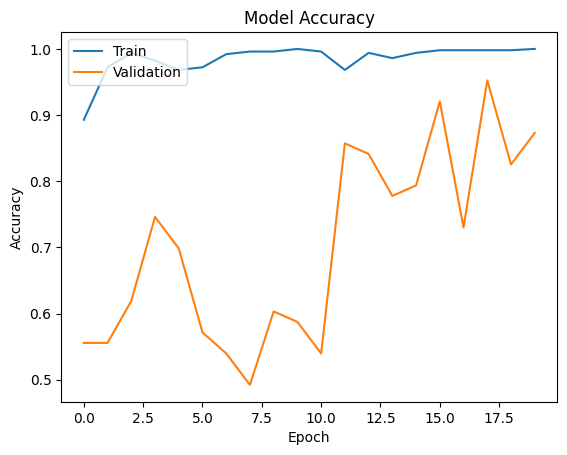

In [ ]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

* The training accuracy steadily increases and stabilizes near 1.0, while the validation accuracy fluctuates significantly with sharp rises and drops, indicating potential overfitting or instability in the model's performance

In [ ]:
# Here we would get the output as probablities for each category
y_pred=model_1.predict(X_test_normalized)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 


###Plotting the Confusion matrix

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


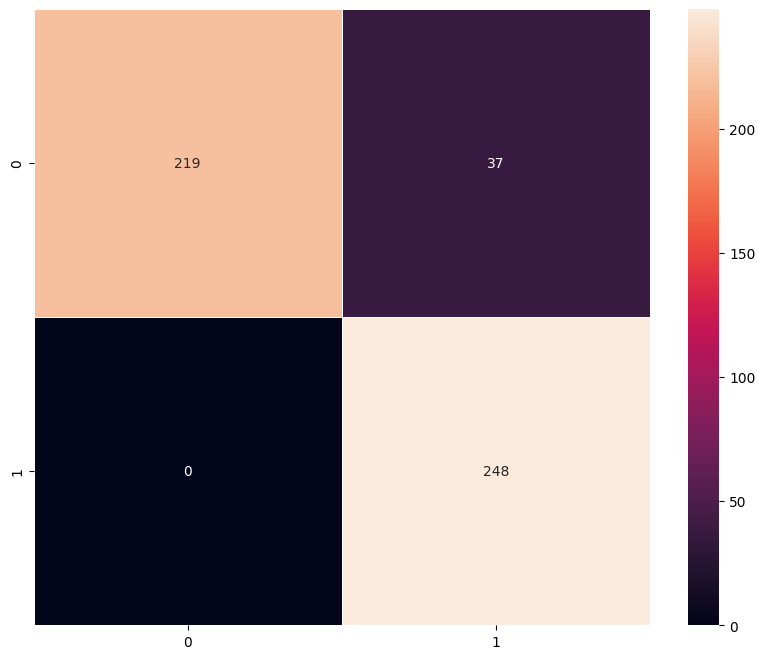

In [ ]:
plot_confusion_matrix(model_1,X_train_normalized,y_train)

In [ ]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)
print("Training performance metrics")
print(model_1_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Training performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.926587  0.926587   0.936118  0.926276


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


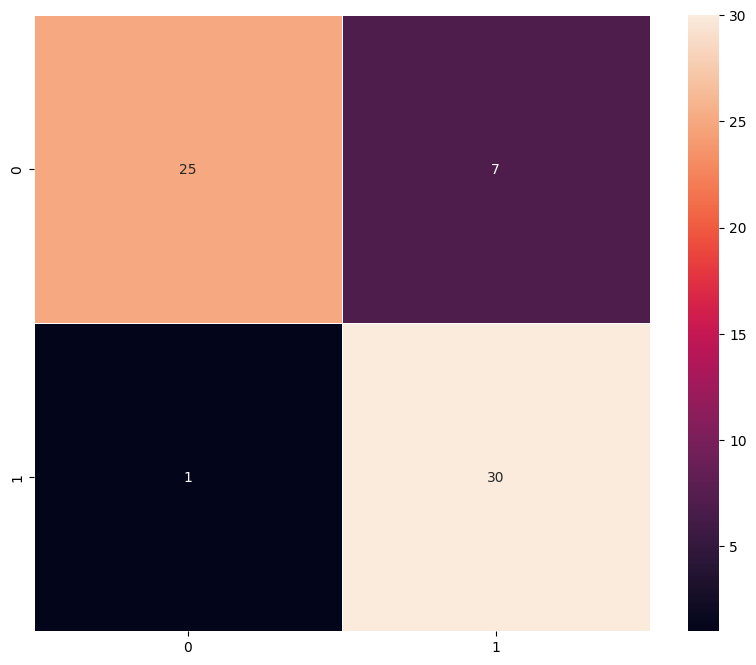

In [ ]:
plot_confusion_matrix(model_1,X_val_normalized,y_val)

In [ ]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_1_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.873016  0.873016   0.887371   0.87205


###Observations
* The model has achieved approximately 92.6% accuracy on the training set and 87.3% accuracy on the validation set.
* Hence the model shows overfitting.

###Visualising the Predictions

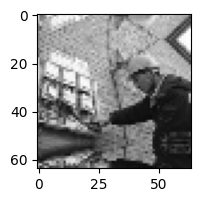

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step
Predicted Label :  With Helmet
True Label : With Helmet


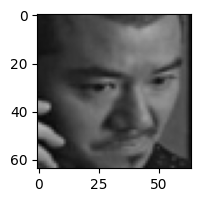

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted Label :  With Helmet
True Label : Without Helmet


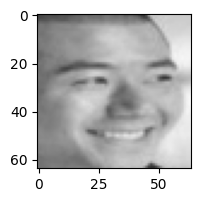

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Label :  Without Helmet
True Label : Without Helmet


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val_normalized[1])
plt.show()
pred=model_1.predict(X_val_normalized[1].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
ypredicted = "With Helmet" if pred >= 0.5 else "Without Helmet"
ytrue="With Helmet" if y_val.iloc[1,0]==1 else "Without Helmet"

print('Predicted Label : ',ypredicted)
print('True Label :', ytrue)

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()

pred=model_1.predict(X_val_normalized[33].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
ypredicted = "With Helmet" if pred >= 0.5 else "Without Helmet"
ytrue="With Helmet" if y_val.iloc[33,0]==1 else "Without Helmet"

print('Predicted Label : ',ypredicted)
print('True Label :', ytrue)


plt.figure(figsize=(2,2))
plt.imshow(X_val[36])
plt.show()

pred=model_1.predict(X_val_normalized[36].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
ypredicted = "With Helmet" if pred >= 0.5 else "Without Helmet"
ytrue="With Helmet" if y_val.iloc[36,0]==1 else "Without Helmet"

print('Predicted Label : ',ypredicted)
print('True Label :', ytrue)

## Model 2: (VGG-16 (Base))

We will be loading a pre-built architecture - **VGG16**, which was trained on the ImageNet dataset and is the runner-up in the ImageNet competition in 2014.

* For training VGG16, we will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten and a single dense layer (output).

* Fully Connected (Dense) Layers:
    * Dense layer with 25 neurons, ReLU activation. Output Layer:

    * Dense layer with 1 neuron, using sigmoid activation — suitable for binary classification.
    * Loss Function : Binary Cross Entropy
    * Optimizer : Adam
    * Batch Size : 128
    * Epoch : 20

In [ ]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

In [ ]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(64,64,3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [ ]:
# Building the model
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

# Adding a dense output layer
model_2.add(Dense(1, activation='sigmoid'))

In [ ]:
opt=Adam()
# Compile model
model_2.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Generating summary of the model
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,716,737 (56.14 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
train_datagen=ImageDataGenerator()

In [ ]:
# Epochs
epochs = 20
# Batch size
batch_size = 128

history_vgg16 = model_2.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5625 - loss: 0.6763 - val_accuracy: 0.8889 - val_loss: 0.5562
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8167 - loss: 0.5656 - val_accuracy: 0.9365 - val_loss: 0.5174
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9119 - loss: 0.5002 - val_accuracy: 0.9524 - val_loss: 0.4211
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9531 - loss: 0.4299 - val_accuracy: 0.9524 - val_loss: 0.3909
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9707 - loss: 0.3706 - val_accuracy: 0.9683 - val_loss: 0.3104
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9750 - loss: 0.3177 - val_accuracy: 0.9841 - val_loss: 0.2885
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9841 - loss: 0.2820 - val_accuracy: 1.0000 - val_loss: 0.2350
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9844 - loss: 0.2394 - val_accuracy: 1.0000 - val_loss: 0.2205
E

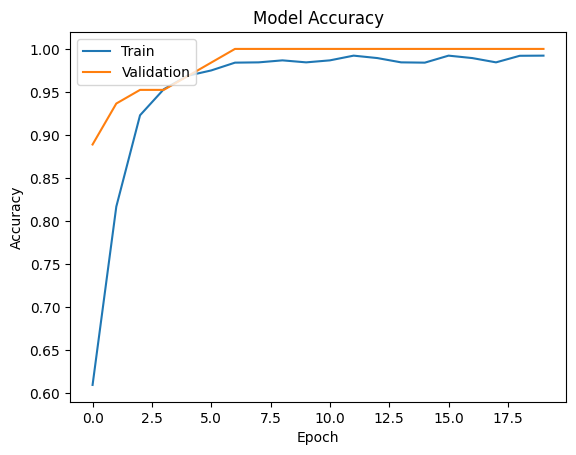

In [ ]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

* There is a rapid improvement in the initial epochs, with training accuracy starting lower but quickly surpassing validation accuracy, and both stabilizing near 1.0 (or 100%) after approximately epoch 6, indicating a well-performing and potentially converged model.

In [ ]:
model_2_train_perf = model_performance_classification(model_2, X_train_normalized,y_train)

print("Train performance metrics")
print(model_2_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.992063  0.992063   0.992063  0.992063


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


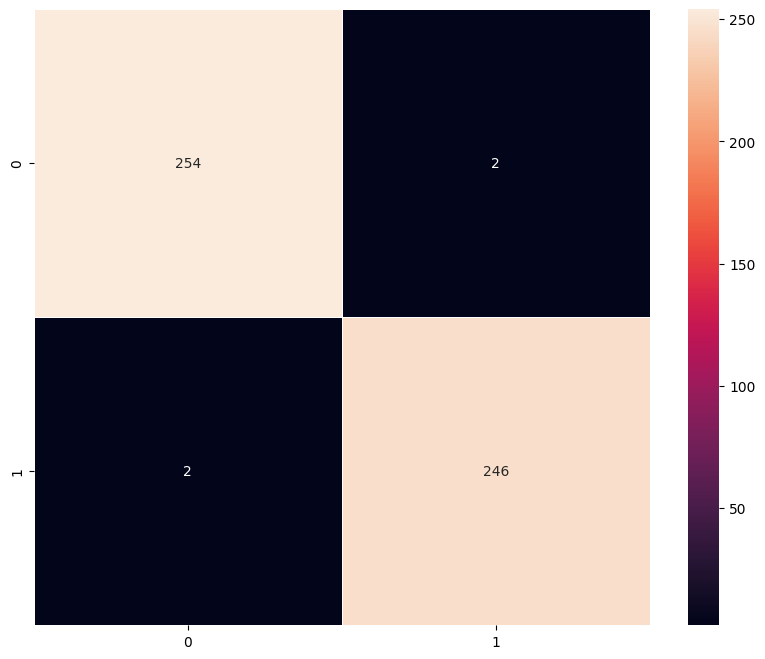

In [ ]:
plot_confusion_matrix(model_2,X_train_normalized,y_train)

In [ ]:
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_2_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 467ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


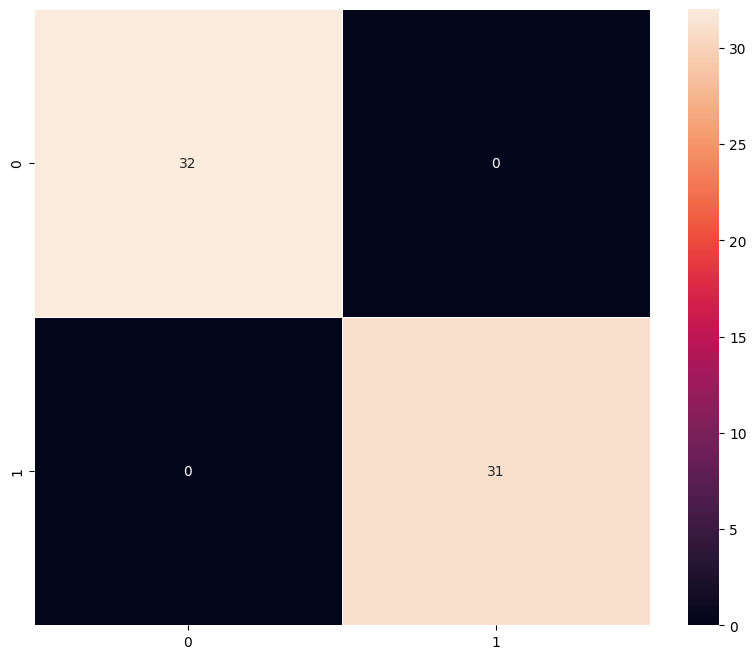

In [ ]:
plot_confusion_matrix(model_2,X_val_normalized,y_val)

### Visualizing the prediction:

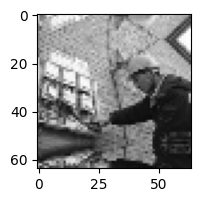

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 999ms/step
Predicted Label :  With Helmet
True Label : With Helmet


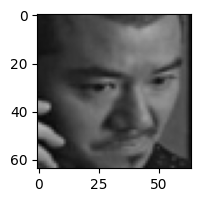

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Label :  Without Helmet
True Label : Without Helmet


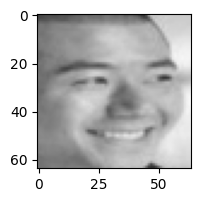

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Label :  Without Helmet
True Label : Without Helmet


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val_normalized[1])
plt.show()
pred=model_2.predict(X_val_normalized[1].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
ypredicted = "With Helmet" if pred >= 0.5 else "Without Helmet"
ytrue="With Helmet" if y_val.iloc[1,0]==1 else "Without Helmet"

print('Predicted Label : ',ypredicted)
print('True Label :', ytrue)

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()

pred=model_2.predict(X_val_normalized[33].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
ypredicted = "With Helmet" if pred >= 0.5 else "Without Helmet"
ytrue="With Helmet" if y_val.iloc[33,0]==1 else "Without Helmet"

print('Predicted Label : ',ypredicted)
print('True Label :', ytrue)


plt.figure(figsize=(2,2))
plt.imshow(X_val[36])
plt.show()

pred=model_2.predict(X_val_normalized[36].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
ypredicted = "With Helmet" if pred >= 0.5 else "Without Helmet"
ytrue="With Helmet" if y_val.iloc[36,0]==1 else "Without Helmet"

print('Predicted Label : ',ypredicted)
print('True Label :', ytrue)

* The model performed well for both training and validation.
* The training shows accuray of 99.2% and validation shows 1 as accuracy.

## Model 3: (VGG-16 (Base + FFNN))



* Let's build a transfer learning model based on VGG16(Base+FFNN), consisting of:

* Pre-trained VGG16 Backbone:
    * The base vgg_model (assumed to be the convolutional part of VGG16, with weights pre-trained on ImageNet and typically frozen) is added as the first layer to extract high-level visual features from input images.
* Flatten Layer: Converts the 3D feature maps output by the VGG16 convolutional base into a 1D feature vector suitable for input into fully connected layers.
* Feed-Forward Neural Network (Custom Head):
    *  Dense layer with 256 neurons and ReLU activation.
    * Dropout layer with a 40% dropout rate to reduce overfitting.
    * Dense layer with 32 neurons and ReLU activation.
* Output Layer:
    *  Dense layer with 1 neuron and sigmoid activation.
    * Loss Function : Binary Cross Entropy
    * Optimizer : Adam
    * Batch Size : 128
    * Epoch : 20

In [ ]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

In [ ]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3.add(Flatten())

#Adding the Feed Forward neural network
model_3.add(Dense(256,activation='relu'))
model_3.add(Dropout(rate=0.4))
model_3.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_3.add(Dense(1, activation='sigmoid'))

In [ ]:
opt=Adam()
# Compile model
model_3.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,247,489 (58.16 MB)

 Trainable params: 532,801 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history_vgg16 = model_3.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5373 - loss: 0.7054 - val_accuracy: 1.0000 - val_loss: 0.1888
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9609 - loss: 0.2301 - val_accuracy: 1.0000 - val_loss: 0.0973
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9882 - loss: 0.1110 - val_accuracy: 1.0000 - val_loss: 0.0155
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9922 - loss: 0.0419 - val_accuracy: 1.0000 - val_loss: 0.0099
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9945 - loss: 0.0248 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0167 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 1.0000 - loss: 0.0108 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 1.0000 - val_loss: 9.1825e-

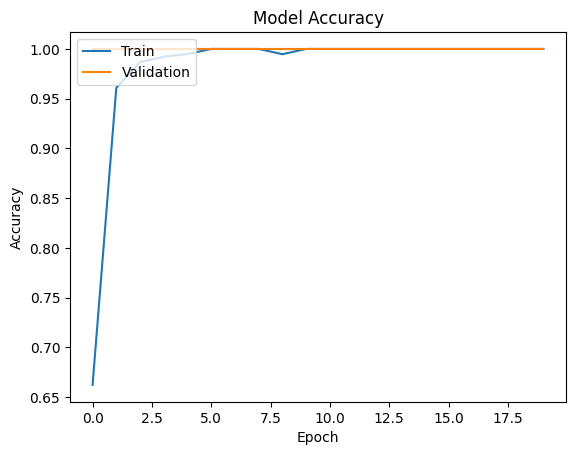

In [ ]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

* Both the training accuracy (blue line) and validation accuracy (orange line) increase rapidly at first, then steady near 100% after about 5 epochs, indicating the model has learned effectively without significant overfitting.

In [ ]:
model_3_train_perf = model_performance_classification(model_3, X_train_normalized,y_train)

print("Train performance metrics")
print(model_3_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


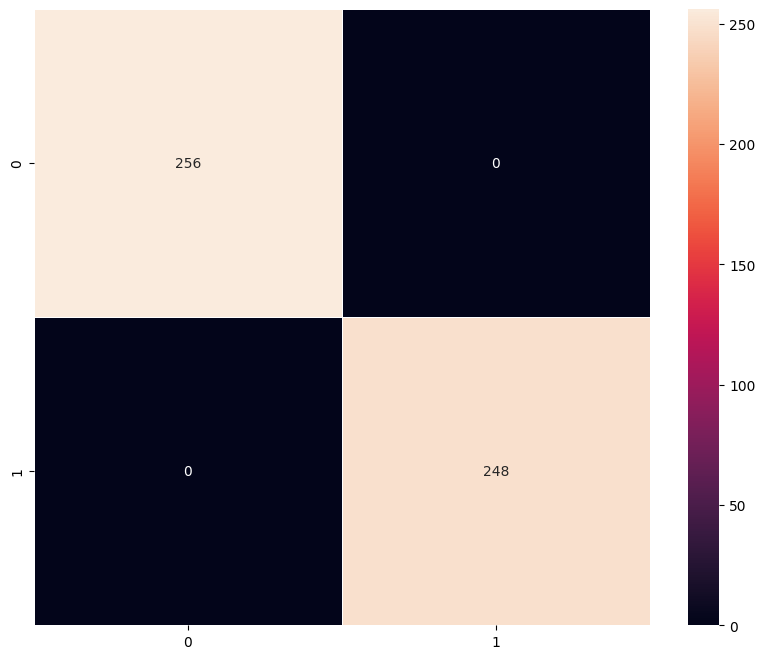

In [ ]:
plot_confusion_matrix(model_3,X_train_normalized,y_train)

In [ ]:
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_3_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


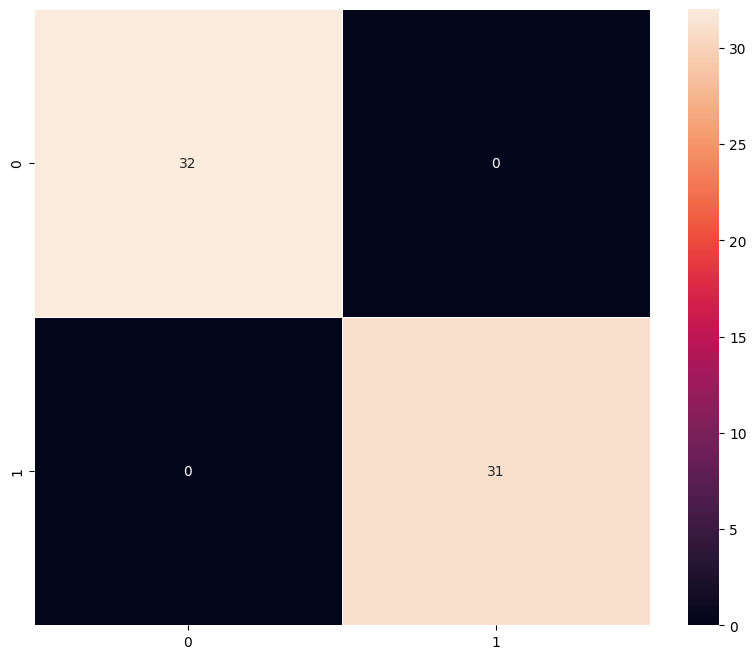

In [ ]:
plot_confusion_matrix(model_3,X_val_normalized,y_val)

#### Visualizing the predictions

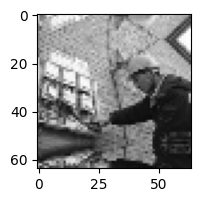

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
Predicted Label :  With Helmet
True Label : With Helmet


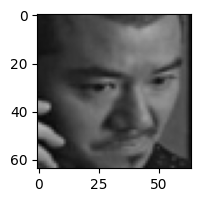

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Label :  Without Helmet
True Label : Without Helmet


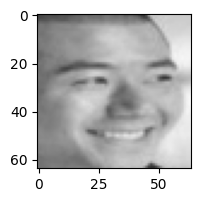

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Label :  Without Helmet
True Label : Without Helmet


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val_normalized[1])
plt.show()
pred=model_3.predict(X_val_normalized[1].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
ypredicted = "With Helmet" if pred >= 0.5 else "Without Helmet"
ytrue="With Helmet" if y_val.iloc[1,0]==1 else "Without Helmet"

print('Predicted Label : ',ypredicted)
print('True Label :', ytrue)

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()

pred=model_3.predict(X_val_normalized[33].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
ypredicted = "With Helmet" if pred >= 0.5 else "Without Helmet"
ytrue="With Helmet" if y_val.iloc[33,0]==1 else "Without Helmet"

print('Predicted Label : ',ypredicted)
print('True Label :', ytrue)


plt.figure(figsize=(2,2))
plt.imshow(X_val[36])
plt.show()

pred=model_3.predict(X_val_normalized[36].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
ypredicted = "With Helmet" if pred >= 0.5 else "Without Helmet"
ytrue="With Helmet" if y_val.iloc[36,0]==1 else "Without Helmet"

print('Predicted Label : ',ypredicted)
print('True Label :', ytrue)

* The model shows accuracy as 1 in both training and validation.
* It shows the significant steady performance.

## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.
- We build the model with the following configuration
    - Feed - Forward Neural Network( Custom Head):
    
      -  Dense layer with 256 neurons and ReLU activation.
      -  Dropout layer with a 40% dropout rate to reduce overfitting.
      -  Dense layer with 32 neurons and ReLU activation.
    - Output Layer:
      -  Dense layer with 1 neuron and sigmoid activation.
    - Loss Function : Binary Cross Entropy
    - Optimizer : Adam
    - Batch Size : 128
    - Epoch : 20

In [ ]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

In [ ]:
model_4= Sequential()

# Adding the convolutional part of the VGG16 model from above
model_4.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_4.add(Flatten())

#Adding the Feed Forward neural network
model_4.add(Dense(256,activation='relu'))
model_4.add(Dropout(rate=0.4))
model_4.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_4.add(Dense(1, activation='sigmoid'))

In [ ]:
opt=Adam()
# Compile model
model_4.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,247,489 (58.16 MB)

 Trainable params: 532,801 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest',
                              width_shift_range=0.2,
                              height_shift_range=0.2,
                              shear_range=0.3,
                              zoom_range=0.4
                              )

In [ ]:
#Building the model
history_vgg16 = model_4.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6373 - loss: 0.6231 - val_accuracy: 0.9683 - val_loss: 0.1836
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9688 - loss: 0.2397 - val_accuracy: 1.0000 - val_loss: 0.0986
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 251ms/step - accuracy: 0.9613 - loss: 0.1853 - val_accuracy: 0.9841 - val_loss: 0.0435
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9083 - loss: 0.1945 - val_accuracy: 1.0000 - val_loss: 0.0268
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.9554 - loss: 0.1218 - val_accuracy: 1.0000 - val_loss: 0.0157
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0381 - val_accuracy: 1.0000 - val_loss: 0.0203
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.9689 - loss: 0.0808 - val_accuracy: 0.9841 - val_loss: 0.0229
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.0293 - val_accuracy: 1.0000 - val_loss: 0.0103

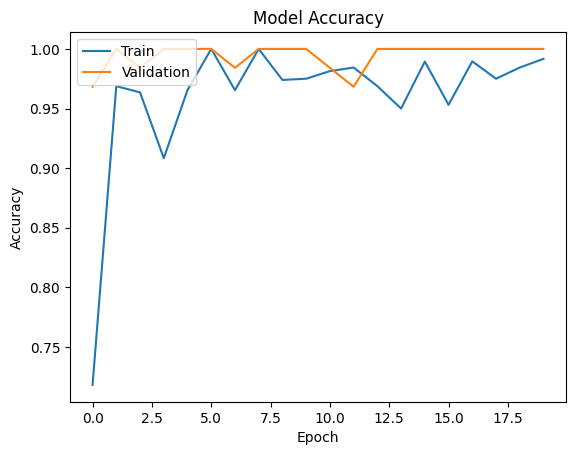

In [ ]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

* Both accuracies start low, rise quickly, and then fluctuate around 0.95 to 1.00, with the validation accuracy generally staying slightly higher than the training accuracy after epoch 5, suggesting the model is learning effectively without significant overfitting.

In [ ]:
model_4_train_perf = model_performance_classification(model_4, X_train_normalized,y_train)

print("Train performance metrics")
print(model_4_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.998016  0.998016   0.998024  0.998016


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


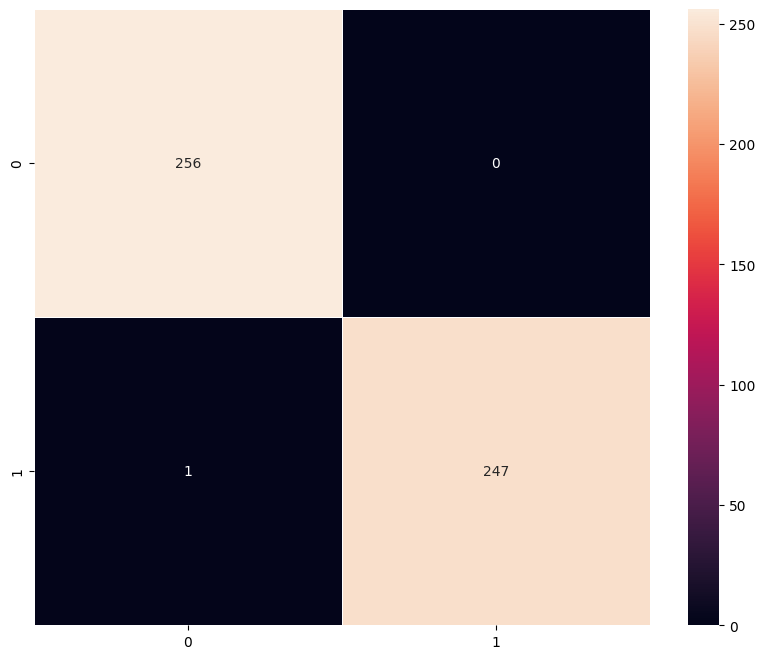

In [ ]:
plot_confusion_matrix(model_4,X_train_normalized,y_train)

In [ ]:
model_4_valid_perf = model_performance_classification(model_4, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_4_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


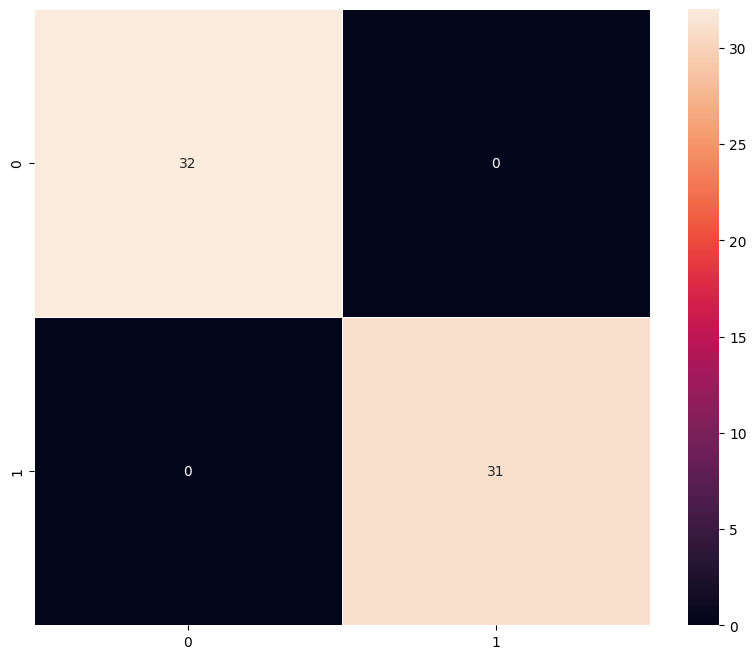

In [ ]:
plot_confusion_matrix(model_4,X_val_normalized,y_val)

#### Visualizing the predictions

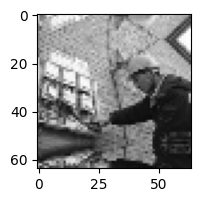

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
Predicted Label :  With Helmet
True Label : With Helmet


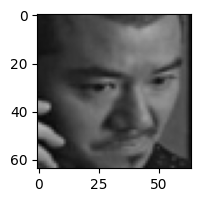

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Label :  Without Helmet
True Label : Without Helmet


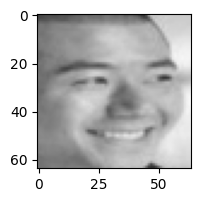

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Label :  Without Helmet
True Label : Without Helmet


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val_normalized[1])
plt.show()
pred=model_4.predict(X_val_normalized[1].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
ypredicted = "With Helmet" if pred >= 0.5 else "Without Helmet"
ytrue="With Helmet" if y_val.iloc[1,0]==1 else "Without Helmet"

print('Predicted Label : ',ypredicted)
print('True Label :', ytrue)

plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()

pred=model_4.predict(X_val_normalized[33].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
ypredicted = "With Helmet" if pred >= 0.5 else "Without Helmet"
ytrue="With Helmet" if y_val.iloc[33,0]==1 else "Without Helmet"

print('Predicted Label : ',ypredicted)
print('True Label :', ytrue)


plt.figure(figsize=(2,2))
plt.imshow(X_val[36])
plt.show()

pred=model_4.predict(X_val_normalized[36].reshape(1,64,64,3)) # reshaping the input image as we are only trying to predict using a single image
# Map to class label
ypredicted = "With Helmet" if pred >= 0.5 else "Without Helmet"
ytrue="With Helmet" if y_val.iloc[36,0]==1 else "Without Helmet"

print('Predicted Label : ',ypredicted)
print('True Label :', ytrue)

* The training accuracy is 99.8 and validation accuracy is 1.
* The model performs well.

# **Model Performance Comparison and Final Model Selection**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
   "CNN","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [ ]:
# training performance comparison

models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T
    ],
    axis=1,
)
models_valid_comp_df.columns = [
   "CNN","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [ ]:
models_train_comp_df

,CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.926587,0.992063,1.0,0.998016
Recall,0.926587,0.992063,1.0,0.998016
Precision,0.936118,0.992063,1.0,0.998024
F1 Score,0.926276,0.992063,1.0,0.998016


In [ ]:
models_valid_comp_df

,CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.873016,1.0,1.0,1.0
Recall,0.873016,1.0,1.0,1.0
Precision,0.887371,1.0,1.0,1.0
F1 Score,0.872050,1.0,1.0,1.0


In [ ]:
models_train_comp_df - models_valid_comp_df

,CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.053571,-0.007937,0.0,-0.001984
Recall,0.053571,-0.007937,0.0,-0.001984
Precision,0.048747,-0.007937,0.0,-0.001976
F1 Score,0.054226,-0.007937,0.0,-0.001984


## Test Performance

In [ ]:
model_2_test_perf = model_performance_classification(model_3, X_test_normalized,y_test)
print("Test performance metrics")
print(model_2_test_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Test performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


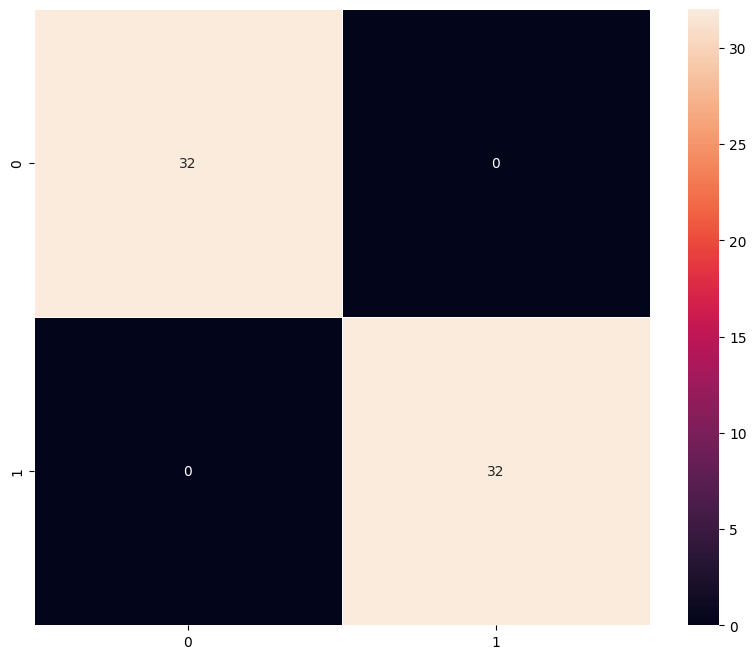

In [ ]:
plot_confusion_matrix(model_3,X_test_normalized,y_test)

# **Actionable Insights & Recommendations**

1. CNN (Simple Convolutional Neural Network)
      * It shows clear signs of overfitting
2. VGG-16 (Base)
      * All VGG-16The transfer learning models are  performed well.The slight negative difference of VGG-16 base shows the inconsistent data.
3. VGG-16 (Base + FFNN)
      * Adding a Feed-Forward Neural Network (FFNN) head on top of VGG-16 allows effective learning of task-specific features. Achieves ideal generalization—no overfitting, no underfitting. Likely well-regularized and properly trained.
4. VGG-16 (Base + FFNN + Data Augmentation)
      * The model performs well in both validation and testing but the difference between performance shows a slight negative differnce.It shhows inconsistent data
      * It provides additional computational task
* Select VGG-16 (Base + FFNN) as the best model because:

  * It achieves perfect training and validation performance.
  * Shows no signs of overfitting.
  * It is simpler and more reliable than the version with data augmentation (which offers additional computational burden).
  * Demonstrates that transfer learning with a trainable head is highly effective for this task.
* Actionable Insight: Avoid unnecessary data augmentation unless validation performance improves.

<font size=5 color='blue'>Power Ahead!</font>
___